In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [8]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [10]:
df.shape

(1460, 81)

In [11]:
corr = df.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


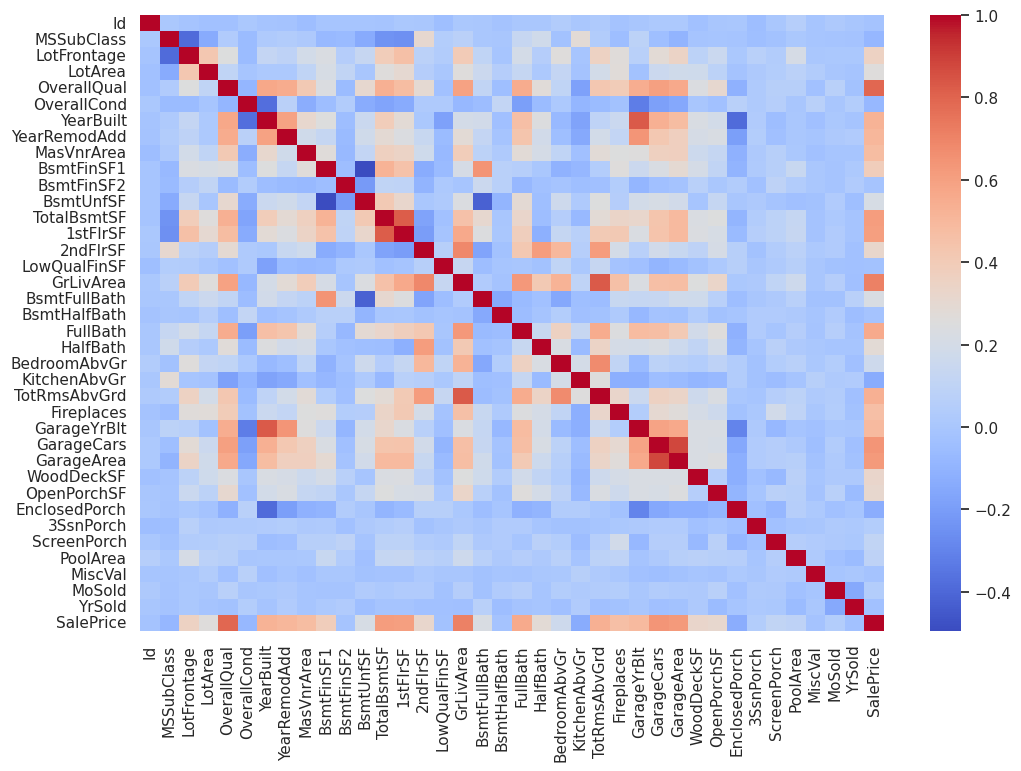

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

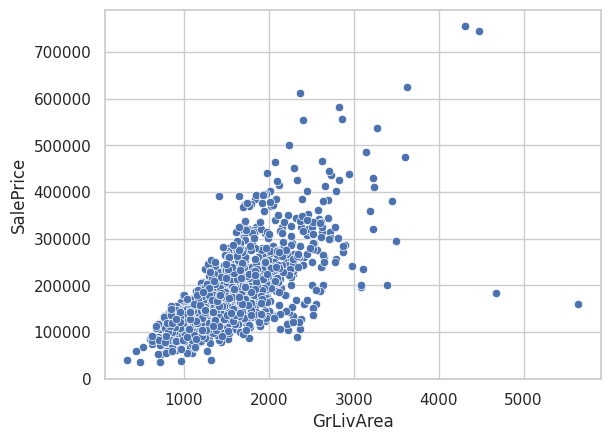

In [13]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()

In [14]:
cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

for col in cols_none:
    df[col] = df[col].fillna("None")

In [15]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [18]:
X = pd.get_dummies(X, drop_first=True)

In [19]:
X = X.fillna(X.median())

In [57]:
y_pred = model.predict(X_test)

In [87]:
weights = (y_train / y_train.mean()) ** 1.5

In [90]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB MAE: 15304.22265625
XGB R2: 0.9167929291725159


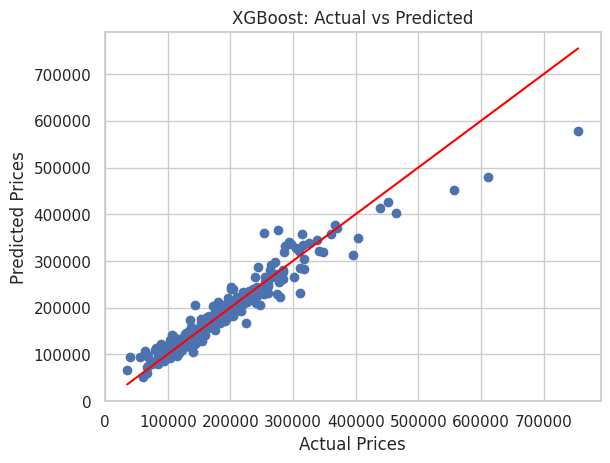

In [92]:
plt.scatter(y_test, y_pred_xgb)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [84]:
expensive = results[results["Actual"] > 400000].copy()

expensive["Error"] = expensive["Actual"] - expensive["Predicted"]
expensive.sort_values(by="Actual", ascending=False)

,Actual,Predicted,Error
691,755000,609152.12500,145847.87500
898,611657,471118.15625,140538.84375
1046,556581,470941.00000,85640.00000
1243,465000,375529.65625,89470.34375
591,451950,373534.71875,78415.28125
58,438780,429960.03125,8819.96875
231,403000,336310.37500,66689.62500


In [89]:
df["LuxuryScore"] = df["OverallQual"] * df["GrLivArea"]
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

In [91]:
(df["SalePrice"] > 600000).sum()

np.int64(4)